In [1]:
"""
Flow Matching vs Classifier — AUC ROC Experiment
=================================================
Pipeline:
  1. Generate a toy 2-class dataset with deliberate overlap
  2. Train a discriminative classifier → AUC = upper bound
  3. Train two separate normalizing flow / flow-matching models (one per class)
  4. Score test points using log p_A(x) - log p_B(x)
  5. Compare both ROC curves

Dependencies: torch, scikit-learn, matplotlib
Install: pip install torch scikit-learn matplotlib
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from tqdm.notebook import trange

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── 1. Toy dataset (two classes, similar distributions) ──────────────────────
def make_toy_dataset(n_samples=2000, overlap=0.6):
    """
    Two 2D Gaussians that partially overlap.
    overlap ∈ [0, 1]: 0 = well-separated, 1 = identical means.
    """
    n = n_samples // 2
    # Class A: centred at (0, 0)
    X_A = np.random.randn(n, 2) * 1.2
    y_A = np.zeros(n)

    # Class B: centred at (overlap, overlap) — closer = harder to separate
    shift = (1.0 - overlap) * 3.0   # overlap=0.6 → shift=1.2
    X_B = np.random.randn(n, 2) * 1.2 + shift
    y_B = np.ones(n)

    X = np.vstack([X_A, X_B]).astype(np.float32)
    y = np.concatenate([y_A, y_B]).astype(np.float32)
    return X, y




In [2]:
X, y = make_toy_dataset(n_samples=2000, overlap=0.6)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

# ─── 2. Discriminative classifier — upper bound ────────────────────────────────
clf = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED)
clf.fit(X_train, y_train)

clf_probs = clf.predict_proba(X_test)[:, 1]
clf_auc   = roc_auc_score(y_test, clf_probs)
clf_fpr, clf_tpr, _ = roc_curve(y_test, clf_probs)

print(f"Classifier AUC: {clf_auc:.4f}  (discriminative upper bound)")


Classifier AUC: 0.7832  (discriminative upper bound)


In [67]:
# ─── 3. Flow Matching — one model per class ────────────────────────────────────
# We implement a simple continuous normalizing flow (CNF) via flow matching.
# The model learns a vector field v_θ(x, t) such that the ODE
#   dx/dt = v_θ(x, t),  x(0) ~ N(0, I),  x(1) ~ p_data
# maps Gaussian noise to data.
#
# At inference we use the change-of-variables formula to compute exact log-likelihood:
#   log p(x) = log p_z(z) - ∫ div(v_θ) dt
# where z = ODE-inverse(x).  We approximate the divergence with Hutchinson's trick.

class MLP(nn.Module):
    """Vector field v_θ(x, t) → R^2"""
    def __init__(self, dim=2, hidden=128, depth=4):
        super().__init__()
        layers = [nn.Linear(dim + 1, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers.append(nn.Linear(hidden, dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        # t: scalar or (B,) tensor
        if t.dim() == 0:
            t = t.expand(x.shape[0])
        t_emb = t.unsqueeze(-1)          # (B, 1)
        return self.net(torch.cat([x, t_emb], dim=-1))


class FlowMatchingModel:
    """
    Trains a simple flow-matching model on a single class.
    Uses Conditional Flow Matching (CFM) loss:
        L = E_{t, x_0~N, x_1~data} [ ||v_θ(x_t, t) - (x_1 - x_0)||² ]
    where x_t = (1-t)*x_0 + t*x_1.
    """
    def __init__(self, dim=2, hidden=128, depth=4, lr=3e-4, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = MLP(dim=dim, hidden=hidden, depth=depth).to(self.device)
        self.opt   = Adam(self.model.parameters(), lr=lr)
        self.dim   = dim

    def train(self, X_class, epochs=400, batch_size=256):
        # Move full dataset once
        data = torch.tensor(X_class, dtype=torch.float32, device=self.device)

        self.model.train()

        for ep in trange(epochs):
            idx = torch.randperm(len(data), device=self.device)[:batch_size]

            x1 = data[idx]                         # data samples (on GPU)
            x0 = torch.randn_like(x1)              # noise (inherits device)
            t  = torch.rand(len(x1), device=self.device)

            t_b = t.unsqueeze(-1)

            x_t = (1 - t_b) * x0 + t_b * x1        # interpolation
            u_t = x1 - x0                          # target velocity

            v_pred = self.model(x_t, t)
            loss   = ((v_pred - u_t) ** 2).mean()

            self.opt.zero_grad()
            loss.backward()
            self.opt.step()

            if (ep + 1) % 100 == 0:
                print(f"  epoch {ep+1:4d} | loss = {loss.item():.5f}")

    #@torch.no_grad()
    def log_prob(self, X, n_steps=50, n_hutchinson=4):
        """
        Reverse-ODE log-likelihood with Hutchinson trace estimator.
 
        Why the original code broke:
          @torch.no_grad() wraps the ENTIRE function body in a no-grad context.
          Inside, torch.autograd.grad() tries to backprop through x_req,
          but since no_grad suppresses all gradient tracking, x_req has no
          grad_fn even after requires_grad_(True) — so autograd raises:
          "element 0 of tensors does not require grad and does not have a grad_fn"
 
        Fix: remove the decorator. Guard only the ODE Euler step with
        torch.no_grad(), keeping the rest of the loop gradient-capable.
        """
        self.model.eval()
        device = next(self.model.parameters()).device

        # Move input to correct device
        if isinstance(X, torch.Tensor):
            x = X.to(device)
        else:
            x = torch.tensor(X, dtype=torch.float32, device=device)

        B = x.shape[0]
        log_det = torch.zeros(B, device=device)
        dt = -1.0 / n_steps

        for step in trange(n_steps):
            # scalar time → must also be on device
            t_val = torch.tensor(1.0 + step * dt, device=device)

            # Hutchinson trace (needs gradients)
            div_est = torch.zeros(B, device=device)
            for _ in range(n_hutchinson):
                eps   = torch.randn_like(x)
                x_req = x.detach().requires_grad_(True)   # fresh leaf
                v     = self.model(x_req, t_val.expand(B))
                vjp   = torch.autograd.grad(
                    (v * eps).sum(), x_req, create_graph=False
                )[0]
                div_est = div_est + (vjp * eps).sum(dim=-1).detach()
            div_est = div_est / n_hutchinson
            log_det = log_det + div_est * dt
 
            # Euler step: move x along the reverse ODE — no grad needed
            with torch.no_grad():
                v_step = self.model(x, t_val.expand(B))
                x      = x + v_step * dt
 
        # x is now approximately z ~ N(0, I)
        with torch.no_grad():
            log_pz = -0.5 * (x ** 2 + np.log(2 * np.pi)).sum(dim=-1)
 
        return (log_pz + log_det).cpu().numpy()




In [10]:
# ─── Train one model per class ─────────────────────────────────────────────────
print("\n── Training Flow Model A (class 0) ──")
flow_A = FlowMatchingModel(dim=2, hidden=128, depth=4)
flow_A.train(X_train[y_train == 0], epochs=500)

print("\n── Training Flow Model B (class 1) ──")
flow_B = FlowMatchingModel(dim=2, hidden=128, depth=4)
flow_B.train(X_train[y_train == 1], epochs=500)

# ─── 4. Score test set with log-likelihood ratio ───────────────────────────────



── Training Flow Model A (class 0) ──


  0%|          | 0/500 [00:00<?, ?it/s]

  epoch  100 | loss = 1.99064
  epoch  200 | loss = 1.85670
  epoch  300 | loss = 1.86035
  epoch  400 | loss = 1.76199
  epoch  500 | loss = 1.94827

── Training Flow Model B (class 1) ──


  0%|          | 0/500 [00:00<?, ?it/s]

  epoch  100 | loss = 2.55122
  epoch  200 | loss = 2.34638
  epoch  300 | loss = 2.25804
  epoch  400 | loss = 2.06735
  epoch  500 | loss = 1.89635


In [29]:
print("\n── Computing log-likelihoods on test set ──")
X_test_t = torch.tensor(X_test, dtype=torch.float32)

logp_A = flow_A.log_prob(X_test, n_steps=20, n_hutchinson=8)
logp_B = flow_B.log_prob(X_test, n_steps=20, n_hutchinson=8)



── Computing log-likelihoods on test set ──


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]


Classifier AUC:          0.7832  ← discriminative upper bound
Flow matching AUC:       0.8009  ← generative likelihood ratio
Gap (upper bound - gen): -0.0177


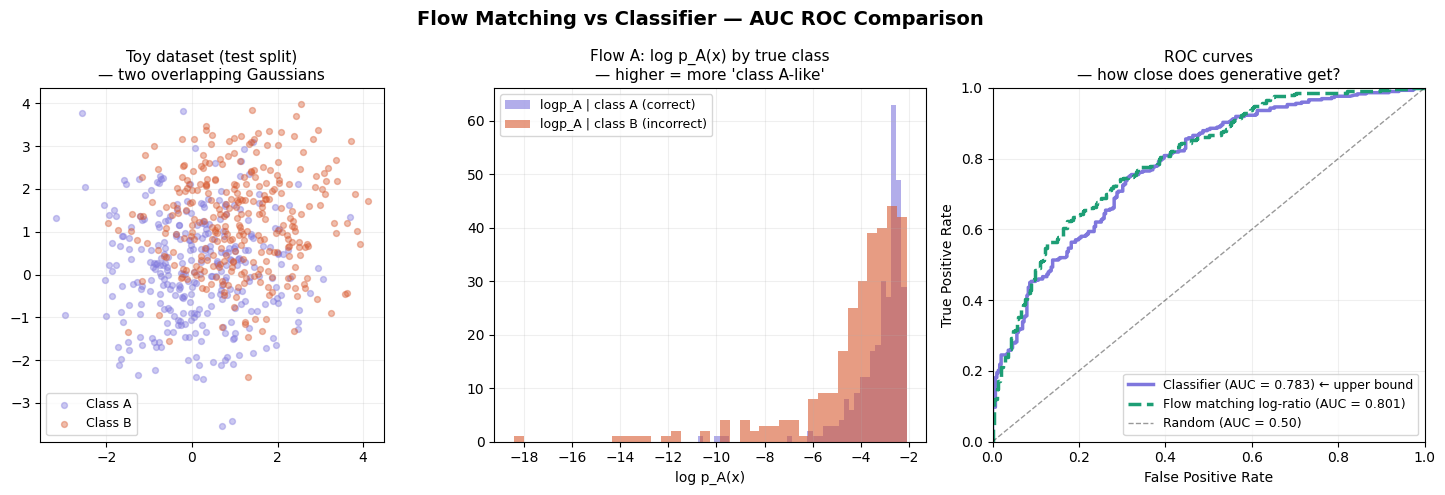


Plot saved to flow_matching_roc.png


In [30]:

# Log-likelihood ratio: positive → more likely class A, negative → more likely B
# We want score high for class 1 (B), so: score = logp_B - logp_A
score_gen = logp_B - logp_A

gen_auc          = roc_auc_score(y_test, score_gen)
gen_fpr, gen_tpr, _ = roc_curve(y_test, score_gen)

print(f"\nClassifier AUC:          {clf_auc:.4f}  ← discriminative upper bound")
print(f"Flow matching AUC:       {gen_auc:.4f}  ← generative likelihood ratio")
print(f"Gap (upper bound - gen): {clf_auc - gen_auc:.4f}")

# ─── 5. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Flow Matching vs Classifier — AUC ROC Comparison", fontsize=14, fontweight="bold")

# --- (a) Dataset ---
ax = axes[0]
mask_A = y_test == 0
mask_B = y_test == 1
ax.scatter(X_test[mask_A, 0], X_test[mask_A, 1], alpha=0.4, s=18, c="#7F77DD", label="Class A")
ax.scatter(X_test[mask_B, 0], X_test[mask_B, 1], alpha=0.4, s=18, c="#D85A30", label="Class B")
ax.set_title("Toy dataset (test split)\n— two overlapping Gaussians", fontsize=11)
ax.legend(fontsize=9)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

# --- (b) Log-likelihood distributions ---
ax = axes[1]
ax.hist(logp_A[y_test == 0], bins=40, alpha=0.6, color="#7F77DD", label="logp_A | class A (correct)")
ax.hist(logp_A[y_test == 1], bins=40, alpha=0.6, color="#D85A30", label="logp_A | class B (incorrect)")
ax.set_title("Flow A: log p_A(x) by true class\n— higher = more 'class A-like'", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlabel("log p_A(x)")
ax.grid(True, alpha=0.2)

# --- (c) ROC curves ---
ax = axes[2]
ax.plot(clf_fpr, clf_tpr, color="#7F77DD", lw=2.5,
        label=f"Classifier (AUC = {clf_auc:.3f}) ← upper bound")
ax.plot(gen_fpr, gen_tpr, color="#1D9E75", lw=2.5, linestyle="--",
        label=f"Flow matching log-ratio (AUC = {gen_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves\n— how close does generative get?", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/flow_matching_roc.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved to flow_matching_roc.png")

Here's the intuition, which I think is more important than the code itself.
Why the classifier sets the upper bound
A discriminative classifier like GBT sees both classes simultaneously and directly optimizes for the boundary between them. It has access to the most useful question: "given this x, which class is more likely?" This is the Bayes-optimal decision rule, so its AUC is the theoretical ceiling for that dataset and feature space.
What the generative approach is actually doing
Instead of learning a boundary, you train two completely separate models — one per class — each trying to learn the full data distribution of that class: p_A(x) and p_B(x). At test time, you score a point by the log-likelihood ratio:
score(x) = log p_B(x) − log p_A(x)
By the Neyman-Pearson lemma, the log-likelihood ratio is the optimal test statistic — so in theory, if both generative models are perfect, the AUC should match the classifier. This is the beautiful theoretical connection: generative likelihood ratios are optimal discriminators.
Why you'll almost always see a gap in practice
The gap comes from three sources:

Model misspecification — your flow model is a parameterized function with finite capacity. If the true class distribution has structure the model can't capture (multimodality, heavy tails), log p̂(x) is a biased estimate of log p(x), and the ratio is distorted.
Finite data — each generative model trains on half the data (one class only), while the classifier trains on all of it and sees the contrast directly.
Approximation in the likelihood computation — the Hutchinson divergence estimator and Euler ODE integration both introduce numerical error. With enough steps and samples these shrink, but they never vanish.

Why do this at all, then?
The discriminative model tells you where the boundary is. The generative model tells you why — it models the full geometry of each class. If your AUC from the generative likelihood ratio is close to the classifier upper bound, it means your flow model has genuinely learned both class distributions well. That's a model quality check you can't do with a classifier alone. The ROC gap is literally a measure of how much information your generative model is losing.
The overlap parameter in the code is the key dial — reduce it and both AUCs go up (the task gets easier), crank it up toward 1.0 and both converge toward 0.5 (the classes become indistinguishable). The gap between the two curves stays driven by model quality, not task difficulty.

In [84]:
# ── 3. Exact divergence of a STOPPED vector field ─────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def exact_div_stopped(net_u, x, t, device=DEVICE):
    """
    div_x( u_theta^-(x, t, t) ) — exact, no Hutchinson.
 
    u^- = stop-gradient on network weights (eq 3.8).
    Computed via dim backward passes with one-hot selectors.
    x, t must already be on `device`.
    Returns (B,) detached tensor on CPU.
    """
    B, dim  = x.shape
    x_leaf  = x.detach().requires_grad_(True)   # stays on device
 
    v   = net_u(x_leaf, t, t)                   # (B, dim) on device
    div = torch.zeros(B, device=device)
 
    for i in range(dim):
        sel    = torch.zeros_like(v)
        sel[:, i] = 1.0
        g = torch.autograd.grad(
            v, x_leaf,
            grad_outputs=sel,
            create_graph=False,
            retain_graph=(i < dim - 1),
        )[0]                                     # (B, dim) on device
        div = div + g[:, i]
 
    return div.detach()    
 


class ShortcutF2D2Net(nn.Module):
    """
    Shared backbone + two heads.
    Input: [x | t | s]  (dim + 2 features)
    u(x,t,s) -> (B, dim)   velocity / shortcut
    D(x,t,s) -> (B,)       accumulated divergence
    """
    def __init__(self, dim=2, hidden=128, depth=4):
        super().__init__()
        layers = [nn.Linear(dim + 2, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        self.backbone = nn.Sequential(*layers)
        self.u_head   = nn.Linear(hidden, dim)
        self.D_head   = nn.Linear(hidden, 1)
 
    def _embed(self, x, t, s):
        B = x.shape[0]
        if t.dim() == 0: t = t.expand(B)
        if s.dim() == 0: s = s.expand(B)
        inp = torch.cat([x, t.unsqueeze(-1), s.unsqueeze(-1)], dim=-1)
        return self.backbone(inp)
 
    def u(self, x, t, s):
        return self.u_head(self._embed(x, t, s))
 
    def D(self, x, t, s):
        return self.D_head(self._embed(x, t, s)).squeeze(-1)
 
 
# ── 5. Algorithm 1: Shortcut-F2D2 Training ────────────────────────────────────
class ShortcutF2D2Model:
    def __init__(self, dim=2, hidden=128, depth=4, lr=3e-4, device=DEVICE):
        self.device = device
        self.dim    = dim
        self.net    = ShortcutF2D2Net(dim=dim, hidden=hidden, depth=depth).to(device)
        self.opt    = Adam(self.net.parameters(), lr=lr)
 
    def train(self, X_class, epochs=600, batch_size=256):
        # Move entire dataset to device once
        data = torch.tensor(X_class, dtype=torch.float32, device=self.device)
        self.net.train()
 
        for ep in trange(epochs, desc="training"):
 
            # ── Line 2 ────────────────────────────────────────────────────────
            idx = torch.randperm(len(data), device=self.device)[:batch_size]
            x1  = data[idx]
            x0  = torch.randn_like(x1)                      # on device
 
            ts  = torch.rand(batch_size, 2, device=self.device)
            t   = ts.min(dim=1).values                      # (B,) on device
            s   = ts.max(dim=1).values
 
            # ── Line 3 ────────────────────────────────────────────────────────
            r = (t + s) / 2.0
 
            # ── Line 4 ────────────────────────────────────────────────────────
            x_t = (1 - t.unsqueeze(-1)) * x0 + t.unsqueeze(-1) * x1
 
            # ── Line 5: Phi(x_t, t, r) = x_t + (r-t)*u(x_t,t,r) ─────────────
            with torch.no_grad():
                x_r = x_t + (r - t).unsqueeze(-1) * self.net.u(x_t, t, r)
 
            # ── Eq 3.7: L_vm-sc ───────────────────────────────────────────────
            u_tt    = self.net.u(x_t, t, t)
            L_vm_sc = ((u_tt - (x1 - x0)) ** 2).mean()
 
            # ── Eq 3.5: L_u-sc ────────────────────────────────────────────────
            u_ts = self.net.u(x_t, t, s)
            with torch.no_grad():
                u_target = 0.5 * (
                    self.net.u(x_t, t, r) +
                    self.net.u(x_r,  r, s)
                )
            L_u_sc = ((u_ts - u_target) ** 2).mean()
 
            # ── Eq 3.8: L_div-sc ──────────────────────────────────────────────
            # exact_div_stopped: x_t and t are already on device
            div_u    = exact_div_stopped(self.net.u, x_t, t, device=self.device)
            D_tt     = self.net.D(x_t, t, t)
            L_div_sc = ((D_tt + div_u) ** 2).mean()
 
            # ── Eq 3.9: L_D-sc ────────────────────────────────────────────────
            D_ts = self.net.D(x_t, t, s)
            with torch.no_grad():
                D_target = 0.5 * (
                    self.net.D(x_t, t, r) +
                    self.net.D(x_r,  r, s)
                )
            L_D_sc = ((D_ts - D_target) ** 2).mean()
 
            # ── Eq 3.10: total ────────────────────────────────────────────────
            loss = L_vm_sc + L_u_sc + L_div_sc + L_D_sc
 
            self.opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=5.0)
            self.opt.step()
 
            if (ep + 1) % 100 == 0:
                print(f"  epoch {ep+1:4d} | loss={loss.item():.5f}  "
                      f"vm={L_vm_sc.item():.4f}  u={L_u_sc.item():.4f}  "
                      f"div={L_div_sc.item():.4f}  D={L_D_sc.item():.4f}")
            
 
    # ── Fast log-likelihood ────────────────────────────────────────────────────
    def log_prob(self, X, n_steps=4):
        """
        log p(x1) = log p_noise(z) - D_theta(x1, 0, 1)
        Reverse ODE in n_steps shortcut steps (t: 1->0) to get z.
        All tensors stay on self.device throughout.
        Returns numpy array on CPU.
        """
        self.net.eval()
        x_orig = torch.tensor(X, dtype=torch.float32, device=self.device)
        B      = x_orig.shape[0]
 
        with torch.no_grad():
            # One-shot accumulated divergence — single forward pass
            D_01 = self.net.D(
                x_orig,
                torch.zeros(B, device=self.device),
                torch.ones(B,  device=self.device)
            )
 
            # Reverse ODE: data -> noise
            x  = x_orig.clone()
            ts = torch.linspace(1.0, 0.0, n_steps + 1, device=self.device)
            for i in trange(n_steps):
                t_i   = ts[i].expand(B)
                t_ip1 = ts[i + 1].expand(B)
                u     = self.net.u(x, t_i, t_ip1)
                x     = x + (ts[i + 1] - ts[i]) * u
 
            log_pz = -0.5 * (x ** 2 + np.log(2 * np.pi)).sum(dim=-1)
 
        return (log_pz - D_01).cpu().numpy()     # back to CPU for sklearn
 
    # ── Algorithm 2: ML Self-Guidance Sampling ─────────────────────────────────
    def sample_with_guidance(self, n_samples=300, n_steps=4, lr_guidance=0.01):
        """
        Lines 1-4: one Adam step on x0 minimising NLL via D_theta
        Lines 5-9: forward shortcut ODE
        All ops on self.device.
        Returns numpy array on CPU.
        """
        self.net.eval()
 
        # Line 1: x0 ~ N(0,I) on device
        x0      = nn.Parameter(torch.randn(n_samples, self.dim, device=self.device))
        adam_x0 = Adam([x0], lr=lr_guidance)
 
        # Lines 2-4
        D_01   = self.net.D(
            x0,
            torch.zeros(n_samples, device=self.device),
            torch.ones(n_samples,  device=self.device)
        )
        log_p0 = -0.5 * (x0 ** 2 + np.log(2 * np.pi)).sum(dim=-1)
        L_NLL  = (-log_p0 - D_01).mean()
        adam_x0.zero_grad()
        L_NLL.backward()
        adam_x0.step()
 
        # Lines 5-9: forward ODE
        x = x0.detach()
        with torch.no_grad():
            ts = torch.linspace(0.0, 1.0, n_steps + 1, device=self.device)
            for i in trange(n_steps, desc="forward ODE", leave=False):
                B     = x.shape[0]
                t_i   = ts[i].expand(B)
                t_ip1 = ts[i + 1].expand(B)
                x     = x + (ts[i + 1] - ts[i]) * self.net.u(x, t_i, t_ip1)
 
        return x.cpu().numpy()                   # back to CPU

In [26]:
# ── Train one Shortcut-F2D2 per class ─────────────────────────────────────────
print("\n── Training Shortcut-F2D2 Model A (class 0) ──")
sf2d2_A = ShortcutF2D2Model(dim=2, hidden=128, depth=4)
sf2d2_A.train(X_train[y_train == 0], epochs=1000)
 
print("\n── Training Shortcut-F2D2 Model B (class 1) ──")
sf2d2_B = ShortcutF2D2Model(dim=2, hidden=128, depth=4)
sf2d2_B.train(X_train[y_train == 1], epochs=1000)
 


── Training Shortcut-F2D2 Model A (class 0) ──


  0%|          | 0/1000 [00:00<?, ?it/s]

  epoch  100 | loss=2.17056  vm=2.1588  u=0.0001  div=0.0116  D=0.0000
  epoch  200 | loss=2.26010  vm=2.2552  u=0.0001  div=0.0047  D=0.0001
  epoch  300 | loss=2.91465  vm=2.4507  u=0.0005  div=0.4632  D=0.0002
  epoch  400 | loss=2.22328  vm=2.0653  u=0.0004  div=0.1573  D=0.0002
  epoch  500 | loss=2.23283  vm=2.1469  u=0.0006  div=0.0847  D=0.0006
  epoch  600 | loss=2.32006  vm=2.0328  u=0.0003  div=0.2867  D=0.0003
  epoch  700 | loss=2.20961  vm=2.0589  u=0.0008  div=0.1496  D=0.0003
  epoch  800 | loss=1.92207  vm=1.8773  u=0.0010  div=0.0422  D=0.0017
  epoch  900 | loss=2.23383  vm=2.0433  u=0.0008  div=0.1884  D=0.0013
  epoch 1000 | loss=2.02193  vm=1.9808  u=0.0007  div=0.0395  D=0.0009

── Training Shortcut-F2D2 Model B (class 1) ──


  0%|          | 0/1000 [00:00<?, ?it/s]

  epoch  100 | loss=2.51341  vm=2.4956  u=0.0018  div=0.0158  D=0.0002
  epoch  200 | loss=2.24393  vm=2.2262  u=0.0022  div=0.0120  D=0.0035
  epoch  300 | loss=2.33876  vm=2.3275  u=0.0025  div=0.0079  D=0.0008
  epoch  400 | loss=2.19270  vm=2.1661  u=0.0011  div=0.0245  D=0.0010
  epoch  500 | loss=2.29035  vm=2.2664  u=0.0021  div=0.0207  D=0.0012
  epoch  600 | loss=2.22146  vm=2.2092  u=0.0024  div=0.0096  D=0.0003
  epoch  700 | loss=2.06489  vm=2.0338  u=0.0027  div=0.0280  D=0.0004
  epoch  800 | loss=1.93560  vm=1.9055  u=0.0024  div=0.0270  D=0.0006
  epoch  900 | loss=1.91767  vm=1.9120  u=0.0028  div=0.0024  D=0.0006
  epoch 1000 | loss=1.99751  vm=1.9869  u=0.0022  div=0.0080  D=0.0004


In [27]:
# ── Score test set ─────────────────────────────────────────────────────────────
print("\n── Computing log-likelihoods (fast, via D_theta head) ──")
logp_A = sf2d2_A.log_prob(X_test, n_steps=4)
logp_B = sf2d2_B.log_prob(X_test, n_steps=4)
 


── Computing log-likelihoods (fast, via D_theta head) ──


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]


Classifier AUC:               0.7832  <- discriminative upper bound
Shortcut-F2D2 AUC (4 steps):  0.8037  <- fast generative LLR
Gap:                          -0.0206

── Sampling with ML self-guidance (Algorithm 2) ──


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

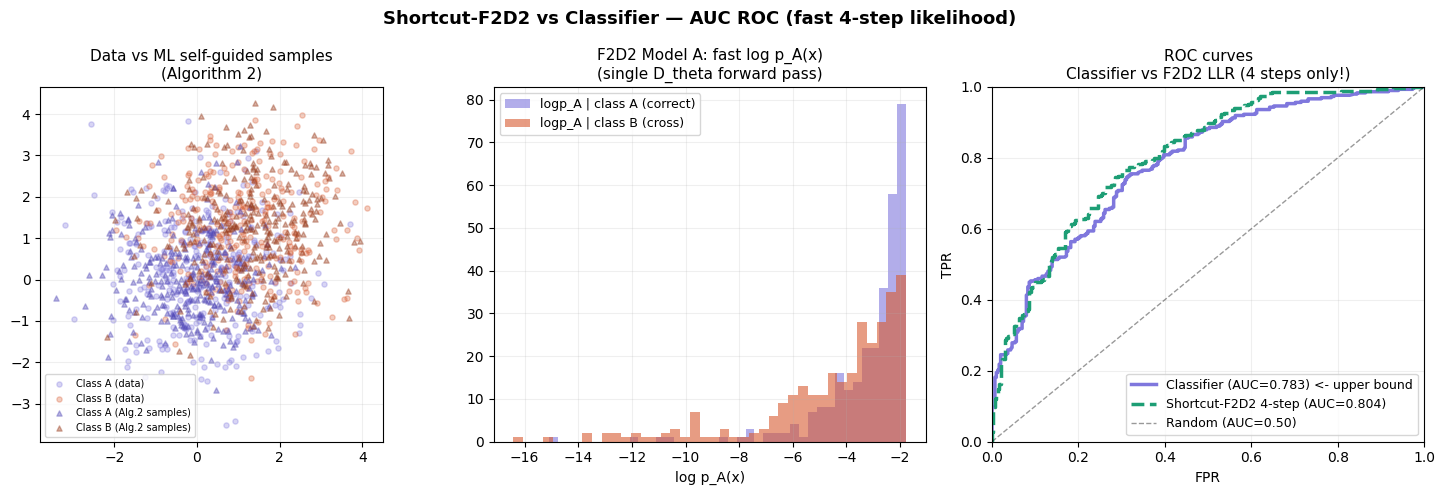

Done — plot saved to shortcut_f2d2_roc.png


In [28]:

score_gen           = logp_B - logp_A
gen_auc             = roc_auc_score(y_test, score_gen)
gen_fpr, gen_tpr, _ = roc_curve(y_test, score_gen)
 
print(f"\nClassifier AUC:               {clf_auc:.4f}  <- discriminative upper bound")
print(f"Shortcut-F2D2 AUC (4 steps):  {gen_auc:.4f}  <- fast generative LLR")
print(f"Gap:                          {clf_auc - gen_auc:.4f}")
 
# ── Samples from Algorithm 2 ───────────────────────────────────────────────────
print("\n── Sampling with ML self-guidance (Algorithm 2) ──")
samples_A = sf2d2_A.sample_with_guidance(n_samples=300, n_steps=4)
samples_B = sf2d2_B.sample_with_guidance(n_samples=300, n_steps=4)
 
# ── Visualise ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Shortcut-F2D2 vs Classifier — AUC ROC (fast 4-step likelihood)",
             fontsize=13, fontweight="bold")
 
# (a) Dataset + guided samples
ax = axes[0]
ax.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1],
           alpha=0.3, s=14, c="#7F77DD", label="Class A (data)")
ax.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1],
           alpha=0.3, s=14, c="#D85A30", label="Class B (data)")
ax.scatter(samples_A[:, 0], samples_A[:, 1],
           alpha=0.4, s=14, marker="^", c="#534AB7", label="Class A (Alg.2 samples)")
ax.scatter(samples_B[:, 0], samples_B[:, 1],
           alpha=0.4, s=14, marker="^", c="#993C1D", label="Class B (Alg.2 samples)")
ax.set_title("Data vs ML self-guided samples\n(Algorithm 2)", fontsize=11)
ax.legend(fontsize=7); ax.set_aspect("equal"); ax.grid(True, alpha=0.2)
 
# (b) D_theta(x, 0, 1) distributions by class
ax = axes[1]
ax.hist(logp_A[y_test==0], bins=40, alpha=0.6, color="#7F77DD",
        label="logp_A | class A (correct)")
ax.hist(logp_A[y_test==1], bins=40, alpha=0.6, color="#D85A30",
        label="logp_A | class B (cross)")
ax.set_title("F2D2 Model A: fast log p_A(x)\n(single D_theta forward pass)", fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel("log p_A(x)"); ax.grid(True, alpha=0.2)
 
# (c) ROC curves
ax = axes[2]
ax.plot(clf_fpr, clf_tpr, color="#7F77DD", lw=2.5,
        label=f"Classifier (AUC={clf_auc:.3f}) <- upper bound")
ax.plot(gen_fpr, gen_tpr, color="#1D9E75", lw=2.5, linestyle="--",
        label=f"Shortcut-F2D2 4-step (AUC={gen_auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.4, label="Random (AUC=0.50)")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC curves\nClassifier vs F2D2 LLR (4 steps only!)", fontsize=11)
ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.2)
 
plt.tight_layout()
plt.show()
print("Done — plot saved to shortcut_f2d2_roc.png")
 

In [31]:
import os
from pathlib import Path

import numpy as np

ROOT_FILE = os.environ.get("PF_GEN_ROOT", "val_1000.root")
if not Path(ROOT_FILE).is_file():
    raise FileNotFoundError(
        f"Set PF_GEN_ROOT or place val_1000.root next to this notebook. Missing: {ROOT_FILE!r}"
    )
print("ROOT:", ROOT_FILE)

ROOT: val_1000.root


In [32]:
from scipy.optimize import linear_sum_assignment


def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return np.arctan2(np.sin(dphi), np.cos(dphi))


def compute_cost_matrix(pf, truth, pf_cls, truth_cls,
                        lambda_dr=2.0, lambda_pt=1.0, class_penalty=2.0):
    pt_pf, eta_pf, phi_pf = pf[:, 0], pf[:, 1], pf[:, 2]
    pt_tr, eta_tr, phi_tr = truth[:, 0], truth[:, 1], truth[:, 2]
    pt_pf = pt_pf[None, :]
    eta_pf = eta_pf[None, :]
    phi_pf = phi_pf[None, :]
    pt_tr = pt_tr[:, None]
    eta_tr = eta_tr[:, None]
    phi_tr = phi_tr[:, None]
    dpt = np.log(pt_pf + 1e-6) - np.log(pt_tr + 1e-6)
    deta = eta_pf - eta_tr
    dphi = delta_phi(phi_pf, phi_tr)
    dr2 = deta**2 + dphi**2
    cost = lambda_dr * dr2 + lambda_pt * (dpt**2)
    class_mismatch = (pf_cls[None, :] != truth_cls[:, None])
    cost += class_penalty * class_mismatch
    return cost


def match_event(pf, truth, pf_cls, truth_cls,
                max_cost=1.5, lambda_dr=2.0, lambda_pt=1.0, class_penalty=1.0):
    if len(pf) == 0 or len(truth) == 0:
        return []
    cost = compute_cost_matrix(
        pf, truth, pf_cls, truth_cls,
        lambda_dr=lambda_dr, lambda_pt=lambda_pt, class_penalty=class_penalty,
    )
    row_ind, col_ind = linear_sum_assignment(cost)
    matches = []
    for r, c in zip(row_ind, col_ind):
        if cost[r, c] < max_cost:
            matches.append((int(r), int(c)))
    return matches


def remap_classes(arr):
    out = np.asarray(arr).copy()
    out[out == 4] = 1
    return out

In [33]:
import uproot


class JetDatasetPreproc:
    """Same valid_idx / filtering as matching.ipynb; matched pairs for truth vs PF."""

    def __init__(
        self,
        filename,
        class_penalty=1.0,
        max_cost=1.5,
        lambda_dr=2.0,
        lambda_pt=1.0,
    ):
        file = uproot.open(filename)
        tree = file["event_tree"]
        self.pt = tree["pflow_pt"].array(library="np")
        self.eta = tree["pflow_eta"].array(library="np")
        self.phi = tree["pflow_phi"].array(library="np")
        self.cls = tree["pflow_class"].array(library="np")
        self.truth_pt = tree["truth_pt"].array(library="np")
        self.truth_eta = tree["truth_eta"].array(library="np")
        self.truth_phi = tree["truth_phi"].array(library="np")
        self.truth_cls = tree["truth_class"].array(library="np")
        self.allowed = np.array([0, 4])
        self.valid_idx = []
        for i in range(len(self.pt)):
            if len(self.pt[i]) == 0 or len(self.truth_pt[i]) == 0:
                continue
            pf_cls = remap_classes(self.cls[i])
            t_cls = remap_classes(self.truth_cls[i])
            pf_mask = np.isin(pf_cls, self.allowed)
            truth_mask = np.isin(t_cls, self.allowed)
            if pf_mask.sum() == 0 or truth_mask.sum() == 0:
                continue
            self.valid_idx.append(i)
        self.class_penalty = float(class_penalty)
        self.max_cost = float(max_cost)
        self.lambda_dr = float(lambda_dr)
        self.lambda_pt = float(lambda_pt)
        print(f"Loaded {len(self.valid_idx)} valid events / {len(self.pt)}")

    def get_matched_unbalanced(self, idx):
        real_idx = self.valid_idx[idx]
        pt, eta, phi = self.pt[real_idx], self.eta[real_idx], self.phi[real_idx]
        pf_cls = self.cls[real_idx]
        t_pt, t_eta, t_phi = self.truth_pt[real_idx], self.truth_eta[real_idx], self.truth_phi[real_idx]
        t_cls = self.truth_cls[real_idx]
        pf_mask = np.isin(pf_cls, self.allowed)
        truth_mask = np.isin(t_cls, self.allowed)
        pt, eta, phi, pf_cls = pt[pf_mask], eta[pf_mask], phi[pf_mask], pf_cls[pf_mask]
        t_pt = t_pt[truth_mask]
        t_eta = t_eta[truth_mask]
        t_phi = t_phi[truth_mask]
        t_cls = t_cls[truth_mask]
        if len(pt) == 0 or len(t_pt) == 0:
            return None
        pf_cls = remap_classes(pf_cls)
        t_cls = remap_classes(t_cls)
        pf = np.stack([pt, eta, phi], axis=1)
        truth = np.stack([t_pt, t_eta, t_phi], axis=1)
        matches = match_event(
            pf,
            truth,
            pf_cls,
            t_cls,
            max_cost=self.max_cost,
            lambda_dr=self.lambda_dr,
            lambda_pt=self.lambda_pt,
            class_penalty=self.class_penalty,
        )
        if len(matches) == 0:
            return None
        kin = []
        targets = []
        pf_labels = []
        for t_idx, p_idx in matches:
            kin.append([
                np.log(pt[p_idx] + 1e-6),
                eta[p_idx],
                np.sin(phi[p_idx]),
                np.cos(phi[p_idx]),
                float(pf_cls[p_idx]),
            ])
            targets.append(int(t_cls[t_idx]))
            pf_labels.append(int(pf_cls[p_idx]))
        return (
            np.asarray(kin, dtype=np.float32),
            np.asarray(targets, dtype=np.int64),
            np.asarray(pf_labels, dtype=np.int64),
        )

    def __len__(self):
        return len(self.valid_idx)

In [34]:
def collect_all_pairs(ds, max_events=None):
    X_kin, y_truth, y_pf = [], [], []
    n = len(ds) if max_events is None else min(len(ds), max_events)
    for i in range(n):
        out = ds.get_matched_unbalanced(i)
        if out is None:
            continue
        kin, tgt, pfl = out
        for row in range(len(kin)):
            X_kin.append(kin[row])
            y_truth.append(tgt[row])
            y_pf.append(pfl[row])
    return (
        np.stack(X_kin, axis=0),
        np.asarray(y_truth, dtype=np.int64),
        np.asarray(y_pf, dtype=np.int64),
    )


# `class_penalty` in Hungarian cost: 0 => geometry + Δlog pT only (no truth–PF class term).
# Use e.g. 1.0 to mimic label-aware matching from `matching.ipynb`.
CLASS_PENALTY_MATCH = 0.0

ds = JetDatasetPreproc(ROOT_FILE, class_penalty=CLASS_PENALTY_MATCH)
print("Hungarian class_penalty:", CLASS_PENALTY_MATCH)
X_all, y_true, y_pf = collect_all_pairs(ds,max_events=5000)
D_GEN = X_all.shape[1]  # 4
print("x shape (kinematics only):", X_all.shape, "D =", D_GEN)
print("truth labels:", np.unique(y_true, return_counts=True))
num_classes = int(y_true.max()) + 1
print("num_classes:", num_classes)

Loaded 239975 valid events / 239996
Hungarian class_penalty: 0.0
x shape (kinematics only): (150501, 5) D = 5
truth labels: (array([0, 1]), array([94250, 56251]))
num_classes: 2


Matched PF baseline accuracy: 0.6812


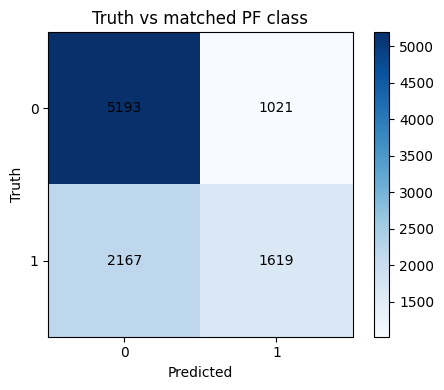

In [37]:
def confusion(y_true, y_pred, K):
    C = np.zeros((K, K), dtype=np.int64)
    for a, b in zip(y_true, y_pred):
        if 0 <= a < K and 0 <= b < K:
            C[a, b] += 1
    return C


def plot_confusion(C, title, labels=None):
    import matplotlib.pyplot as plt

    K = C.shape[0]
    if labels is None:
        labels = [str(i) for i in range(K)]
    plt.figure(figsize=(5, 4))
    plt.imshow(C, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.xticks(range(K), labels)
    plt.yticks(range(K), labels)
    for i in range(K):
        for j in range(K):
            plt.text(j, i, int(C[i, j]), ha="center", va="center", color="black")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Nevents = 10000
C_pf = confusion(y_true[:Nevents], y_pf[:Nevents], num_classes)
acc_pf = np.trace(C_pf) / max(C_pf.sum(), 1)
print(f"Matched PF baseline accuracy: {acc_pf:.4f}")
plot_confusion(C_pf, "Truth vs matched PF class")

### 1) Diagonal Gaussian generative model \(p(x\mid y)\)

Closed-form MLE: per class, mean and variance (with epsilon floor). Then
\(\log p(x\mid y) = \sum_d \big[-\tfrac12\log(2\pi\sigma^2_{y,d}) - \tfrac{(x_d-\mu_{y,d})^2}{2\sigma^2_{y,d}}\big]\).

empirical priors: [0.62627076 0.37372924]
Diagonal-Gaussian generative (Bayes): acc=0.7002


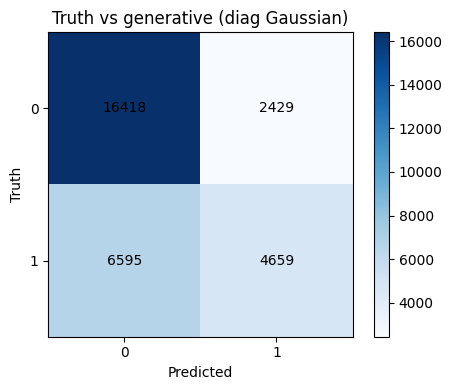

NP LR == Bayes w/ equal priors: True


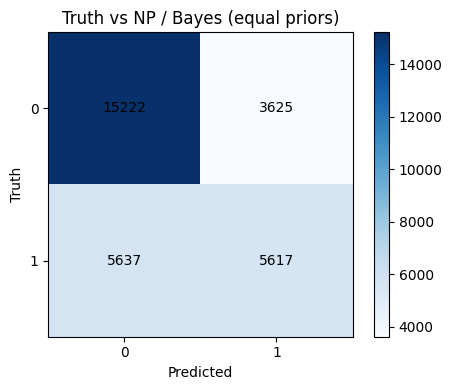

In [38]:
def fit_diag_gaussian(X, y, num_classes, eps=1e-3):
    D = X.shape[1]
    mu = np.zeros((num_classes, D), dtype=np.float64)
    var = np.ones((num_classes, D), dtype=np.float64)
    for c in range(num_classes):
        m = y == c
        if m.sum() < 2:
            mu[c] = X.mean(axis=0)
            var[c] = X.var(axis=0) + eps
            continue
        mu[c] = X[m].mean(axis=0)
        var[c] = X[m].var(axis=0) + eps
    return mu, var


def logpx_given_y_diag(X, mu, var):
    # X: (N,D), mu/var: (C,D) -> log p(x|y=c): (N,C)
    N, D = X.shape
    C = mu.shape[0]
    out = np.zeros((N, C), dtype=np.float64)
    for c in range(C):
        diff = X - mu[c]
        out[:, c] = -0.5 * np.sum(np.log(2 * np.pi * var[c]) + (diff ** 2) / var[c], axis=1)
    return out


rng = np.random.default_rng(0)
perm = rng.permutation(len(X_all))
n_train = int(0.8 * len(perm))
tr, te = perm[:n_train], perm[n_train:]
X_tr, y_tr = X_all[tr], y_true[tr]
X_te, y_te = X_all[te], y_true[te]
y_pf_te = y_pf[te]

pi = np.bincount(y_tr, minlength=num_classes).astype(np.float64)
pi = pi / pi.sum()
print("empirical priors:", pi)

mu_g, var_g = fit_diag_gaussian(X_tr, y_tr, num_classes)
logp_te = logpx_given_y_diag(X_te, mu_g, var_g)
log_joint = logp_te + np.log(pi + 1e-12)
y_hat_g = log_joint.argmax(axis=1)

C_g = confusion(y_te, y_hat_g, num_classes)
acc_g = np.trace(C_g) / max(C_g.sum(), 1)
print(f"Diagonal-Gaussian generative (Bayes): acc={acc_g:.4f}")
plot_confusion(C_g, "Truth vs generative (diag Gaussian)")

if num_classes == 2:
    lr = logp_te[:, 1] - logp_te[:, 0]
    y_np = (lr > 0).astype(np.int64)
    y_bayes_equal = logp_te.argmax(axis=1)
    print("NP LR == Bayes w/ equal priors:", np.all(y_np == y_bayes_equal))
    plot_confusion(confusion(y_te, y_np, 2), "Truth vs NP / Bayes (equal priors)")

In [39]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class Coupling(nn.Module):
    """Affine coupling on second half; condition on y via embedding."""

    def __init__(self, dim, split_dim, num_classes, hidden, emb_dim=32):
        super().__init__()
        self.dim = dim
        self.split_dim = split_dim
        self.d2 = dim - split_dim
        self.emb = nn.Embedding(num_classes, emb_dim)
        self.net = nn.Sequential(
            nn.Linear(split_dim + emb_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2 * self.d2),
        )

    def forward(self, x, y, reverse=False):
        x1, x2 = x[:, : self.split_dim], x[:, self.split_dim :]
        e = self.emb(y)
        h = self.net(torch.cat([x1, e], dim=1))
        log_s, t = h[:, : self.d2], h[:, self.d2 :]
        s = torch.tanh(log_s)
        if not reverse:
            y2 = x2 * torch.exp(s) + t
            logdet = s.sum(dim=1)
        else:
            y2 = (x2 - t) * torch.exp(-s)
            logdet = -s.sum(dim=1)
        return torch.cat([x1, y2], dim=1), logdet


class ConditionalRealNVP(nn.Module):
    def __init__(self, dim=4, num_classes=2, hidden=128):
        super().__init__()
        self.dim = dim
        self.num_classes = num_classes
        self.c1 = Coupling(dim, 2, num_classes, hidden)
        self.c2 = Coupling(dim, 2, num_classes, hidden)

    def _forward(self, x, y):
        z, ld = self.c1(x, y)
        z = torch.cat([z[:, 2:], z[:, :2]], dim=1)
        z, ld2 = self.c2(z, y)
        z = torch.cat([z[:, 2:], z[:, :2]], dim=1)
        return z, ld + ld2

    def log_prob(self, x, y):
        z, logdet = self._forward(x, y)
        d = z.shape[1]
        log_pz = -0.5 * (z ** 2 + math.log(2 * math.pi)).sum(dim=1)
        return log_pz + logdet

    def log_prob_all_classes(self, x):
        N = x.shape[0]
        C = self.num_classes
        outs = []
        for c in range(C):
            y = torch.full((N,), c, dtype=torch.long, device=x.device)
            outs.append(self.log_prob(x, y))
        return torch.stack(outs, dim=1)


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D_GEN = X_all.shape[1]  # 5
flow = ConditionalRealNVP(dim=D_GEN, num_classes=num_classes, hidden=128).to(device)
opt = torch.optim.Adam(flow.parameters(), lr=1e-3)

Xtr = torch.tensor(X_tr, dtype=torch.float32, device=device)
ytr = torch.tensor(y_tr, dtype=torch.long, device=device)



In [41]:
flow.train()
bs = 512
for epoch in trange(60):
    perm = torch.randperm(len(Xtr), device=device)
    tot = 0.0
    n = 0
    for s in range(0, len(Xtr), bs):
        idx = perm[s : s + bs]
        xb, yb = Xtr[idx], ytr[idx]
        lp = flow.log_prob(xb, yb)
        loss = -lp.mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        tot += float(loss.item()) * len(idx)
        n += len(idx)
    if epoch % 20 == 0:
        print(f"epoch {epoch} nll {tot / max(n, 1):.4f}")



  0%|          | 0/60 [00:00<?, ?it/s]

epoch 0 nll 5.2460
epoch 20 nll 3.4035
epoch 40 nll 3.3910


In [43]:

def bayes_rule_from_log_likelihood(log_p_x_given_y, pi):
    pi = np.asarray(pi, dtype=np.float64)
    pi = pi / pi.sum()
    joint = log_p_x_given_y + np.log(pi + 1e-300)[None, :]
    return joint.argmax(axis=1)


NP/Bayes-optimal under RealNVP (4D kin.): acc=0.6885


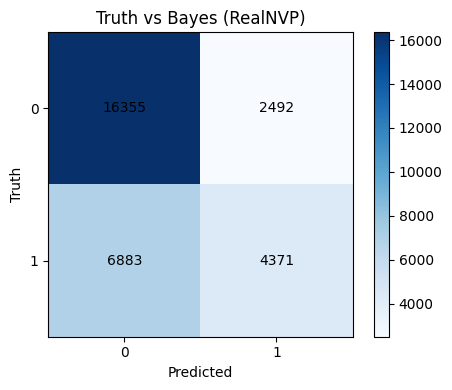

In [44]:
flow.eval()
Xev = torch.tensor(X_te, dtype=torch.float32, device=device)
with torch.no_grad():
    logp_f_te = flow.log_prob_all_classes(Xev).cpu().numpy()

y_hat_f = bayes_rule_from_log_likelihood(logp_f_te, pi)
C_f = confusion(y_te, y_hat_f, num_classes)
acc_f = np.trace(C_f) / max(C_f.sum(), 1)
print(f"NP/Bayes-optimal under RealNVP (4D kin.): acc={acc_f:.4f}")
plot_confusion(C_f, "Truth vs Bayes (RealNVP)")

In [69]:
# ─── Train one model per class ─────────────────────────────────────────────────
print("\n── Training Flow Model A (class 0) ──")
Xtr = Xtr.to(device)
ytr = ytr.to(device)
flow_A = FlowMatchingModel(dim=Xtr.shape[1], hidden=128, depth=4)
flow_A.train(Xtr[ytr == 0], epochs=500)

print("\n── Training Flow Model B (class 1) ──")
flow_B = FlowMatchingModel(dim=Xtr.shape[1], hidden=128, depth=4)
flow_B.train(Xtr[ytr == 1], epochs=500)


── Training Flow Model A (class 0) ──


/tmp/ipykernel_521/4262752414.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(X_class, dtype=torch.float32, device=self.device)


  0%|          | 0/500 [00:00<?, ?it/s]

  epoch  100 | loss = 1.61235
  epoch  200 | loss = 1.49065
  epoch  300 | loss = 1.34184
  epoch  400 | loss = 1.36863
  epoch  500 | loss = 1.38805

── Training Flow Model B (class 1) ──


  0%|          | 0/500 [00:00<?, ?it/s]

  epoch  100 | loss = 1.50299
  epoch  200 | loss = 1.34355
  epoch  300 | loss = 1.31140
  epoch  400 | loss = 1.17601
  epoch  500 | loss = 1.33564


In [70]:


logp_A = flow_A.log_prob(Xev, n_steps=20, n_hutchinson=8)
logp_B = flow_B.log_prob(Xev, n_steps=20, n_hutchinson=8)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Generative LLR AUC: 0.7012
Optimal threshold (Youden J): -0.2242

Confusion matrix:
[[12685  6162]
 [ 4143  7111]]

  Accuracy:    0.6577
  Precision:   0.5357
  Recall/TPR:  0.6319
  Specificity: 0.6731
  F1:          0.5799


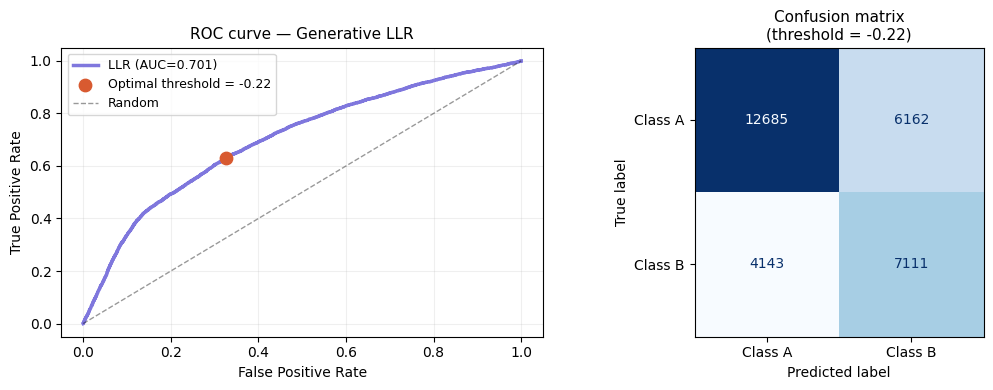

In [72]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ── Score ──────────────────────────────────────────────────────────────────────
# log-likelihood ratio: positive -> more class B, negative -> more class A
score = logp_B - logp_A   # (N,)

# ── AUC ROC ───────────────────────────────────────────────────────────────────
# yev must be your true labels for Xev (0 = class A, 1 = class B)
auc = roc_auc_score(y_te, score)
fpr, tpr, thresholds = roc_curve(y_te, score)
print(f"Generative LLR AUC: {auc:.4f}")

# ── Threshold: pick the point closest to (FPR=0, TPR=1) ──────────────────────
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden J): {optimal_threshold:.4f}")

y_pred = (score >= optimal_threshold).astype(int)

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred)
print("\nConfusion matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\n  Accuracy:    {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"  Precision:   {tp/(tp+fp):.4f}")
print(f"  Recall/TPR:  {tp/(tp+fn):.4f}")
print(f"  Specificity: {tn/(tn+fp):.4f}")
print(f"  F1:          {2*tp/(2*tp+fp+fn):.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(fpr, tpr, color="#7F77DD", lw=2.5, label=f"LLR (AUC={auc:.3f})")
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color="#D85A30", s=80, zorder=5,
           label=f"Optimal threshold = {optimal_threshold:.2f}")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4,label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — Generative LLR", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Class A", "Class B"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion matrix\n(threshold = {optimal_threshold:.2f})", fontsize=11)

plt.tight_layout()
#plt.savefig("llr_auc_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [92]:
# ── Train one Shortcut-F2D2 per class ─────────────────────────────────────────
print("\n── Training Shortcut-F2D2 Model A (class 0) ──")
sf2d2_A = ShortcutF2D2Model(dim=Xtr.shape[1], hidden=128, depth=4)
sf2d2_A.train(Xtr[ytr == 0], epochs=2000)
 
print("\n── Training Shortcut-F2D2 Model B (class 1) ──")
sf2d2_B = ShortcutF2D2Model(dim=Xtr.shape[1], hidden=128, depth=4)
sf2d2_B.train(Xtr[ytr == 0], epochs=2000)


── Training Shortcut-F2D2 Model A (class 0) ──


/tmp/ipykernel_521/3898929450.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(X_class, dtype=torch.float32, device=self.device)


training:   0%|          | 0/2000 [00:00<?, ?it/s]

  epoch  100 | loss=1.71046  vm=1.6448  u=0.0021  div=0.0620  D=0.0016
  epoch  200 | loss=1.21367  vm=1.2024  u=0.0031  div=0.0076  D=0.0006
  epoch  300 | loss=1.22263  vm=1.2138  u=0.0042  div=0.0042  D=0.0004
  epoch  400 | loss=1.17689  vm=1.1654  u=0.0066  div=0.0033  D=0.0015
  epoch  500 | loss=1.16034  vm=1.1512  u=0.0053  div=0.0034  D=0.0005
  epoch  600 | loss=1.21792  vm=1.2088  u=0.0054  div=0.0028  D=0.0009
  epoch  700 | loss=1.21426  vm=1.2063  u=0.0036  div=0.0036  D=0.0008
  epoch  800 | loss=1.29050  vm=1.2820  u=0.0031  div=0.0030  D=0.0024
  epoch  900 | loss=1.05379  vm=1.0439  u=0.0024  div=0.0052  D=0.0023
  epoch 1000 | loss=1.15457  vm=1.1477  u=0.0019  div=0.0024  D=0.0025
  epoch 1100 | loss=1.31621  vm=1.3076  u=0.0017  div=0.0046  D=0.0023
  epoch 1200 | loss=1.15304  vm=1.1443  u=0.0019  div=0.0043  D=0.0026
  epoch 1300 | loss=1.16340  vm=1.1536  u=0.0015  div=0.0057  D=0.0026
  epoch 1400 | loss=1.18367  vm=1.1735  u=0.0019  div=0.0054  D=0.0029
  epoc

training:   0%|          | 0/2000 [00:00<?, ?it/s]

  epoch  100 | loss=1.53720  vm=1.5227  u=0.0002  div=0.0143  D=0.0000
  epoch  200 | loss=1.33135  vm=1.3125  u=0.0034  div=0.0141  D=0.0013
  epoch  300 | loss=1.39310  vm=1.3822  u=0.0039  div=0.0066  D=0.0003
  epoch  400 | loss=1.28762  vm=1.2786  u=0.0049  div=0.0035  D=0.0006
  epoch  500 | loss=1.10073  vm=1.0886  u=0.0064  div=0.0035  D=0.0023
  epoch  600 | loss=1.20145  vm=1.1886  u=0.0088  div=0.0028  D=0.0013
  epoch  700 | loss=1.21866  vm=1.2087  u=0.0062  div=0.0029  D=0.0008
  epoch  800 | loss=1.13006  vm=1.1231  u=0.0037  div=0.0023  D=0.0011
  epoch  900 | loss=1.16364  vm=1.1561  u=0.0024  div=0.0039  D=0.0013
  epoch 1000 | loss=1.22269  vm=1.2163  u=0.0020  div=0.0033  D=0.0010
  epoch 1100 | loss=1.14289  vm=1.1323  u=0.0027  div=0.0059  D=0.0020
  epoch 1200 | loss=1.19178  vm=1.1836  u=0.0013  div=0.0048  D=0.0020
  epoch 1300 | loss=1.20100  vm=1.1893  u=0.0018  div=0.0082  D=0.0017
  epoch 1400 | loss=1.16041  vm=1.1523  u=0.0016  div=0.0046  D=0.0020
  epoc

In [96]:
# ── Score test set ─────────────────────────────────────────────────────────────
print("\n── Computing log-likelihoods (fast, via D_theta head) ──")
logp_f2d2_A = sf2d2_A.log_prob(Xev, n_steps=10)
logp_f2d2_B = sf2d2_B.log_prob(Xev, n_steps=10)
 


── Computing log-likelihoods (fast, via D_theta head) ──


/tmp/ipykernel_521/3898929450.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_orig = torch.tensor(X, dtype=torch.float32, device=self.device)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [97]:
score_gen

array([-0.60227203, -0.81620693, -0.49207878, ...,  0.20454502,
        0.0726614 , -0.7193575 ], shape=(30101,), dtype=float32)

In [98]:
score_gen           = logp_f2d2_B - logp_f2d2_A
gen_auc             = roc_auc_score(y_te, score_gen)
gen_fpr, gen_tpr, _ = roc_curve(y_te, score_gen)
 
print(f"Shortcut-F2D2 AUC (4 steps):  {gen_auc:.4f}  <- fast generative LLR")
 
# ── Samples from Algorithm 2 ───────────────────────────────────────────────────
print("\n── Sampling with ML self-guidance (Algorithm 2) ──")
samples_A = sf2d2_A.sample_with_guidance(n_samples=300, n_steps=4)
samples_B = sf2d2_B.sample_with_guidance(n_samples=300, n_steps=4)

Shortcut-F2D2 AUC (4 steps):  0.6560  <- fast generative LLR

── Sampling with ML self-guidance (Algorithm 2) ──


forward ODE:   0%|          | 0/4 [00:00<?, ?it/s]

forward ODE:   0%|          | 0/4 [00:00<?, ?it/s]

Generative LLR AUC: 0.6560
Optimal threshold (Youden J): -0.6414

Confusion matrix:
[[10293  8554]
 [ 3492  7762]]

  Accuracy:    0.5998
  Precision:   0.4757
  Recall/TPR:  0.6897
  Specificity: 0.5461
  F1:          0.5631


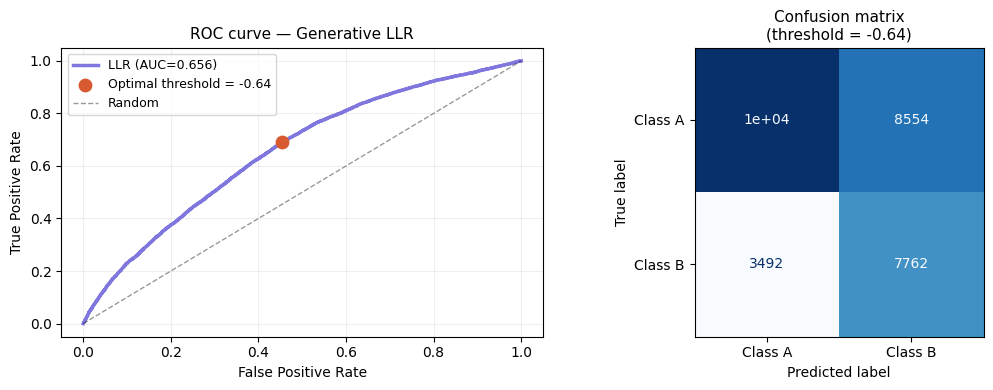

In [99]:
# ── Score ──────────────────────────────────────────────────────────────────────
# log-likelihood ratio: positive -> more class B, negative -> more class A
score = logp_f2d2_B - logp_f2d2_A   # (N,)

# ── AUC ROC ───────────────────────────────────────────────────────────────────
# yev must be your true labels for Xev (0 = class A, 1 = class B)
auc = roc_auc_score(y_te, score)
fpr, tpr, thresholds = roc_curve(y_te, score)
print(f"Generative LLR AUC: {auc:.4f}")

# ── Threshold: pick the point closest to (FPR=0, TPR=1) ──────────────────────
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden J): {optimal_threshold:.4f}")

y_pred = (score >= optimal_threshold).astype(int)

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_te, y_pred)
print("\nConfusion matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\n  Accuracy:    {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"  Precision:   {tp/(tp+fp):.4f}")
print(f"  Recall/TPR:  {tp/(tp+fn):.4f}")
print(f"  Specificity: {tn/(tn+fp):.4f}")
print(f"  F1:          {2*tp/(2*tp+fp+fn):.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(fpr, tpr, color="#7F77DD", lw=2.5, label=f"LLR (AUC={auc:.3f})")
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color="#D85A30", s=80, zorder=5,
           label=f"Optimal threshold = {optimal_threshold:.2f}")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4,label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve — Generative LLR", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Class A", "Class B"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion matrix\n(threshold = {optimal_threshold:.2f})", fontsize=11)

plt.tight_layout()
#plt.savefig("llr_auc_confusion.png", dpi=150, bbox_inches="tight")
plt.show()